# PJM LMP Data Validation — dense hourly-completeness grid (DOM vs AEP)

A quick visual + tabular check of whether every expected hourly row actually landed —
for `pjm_da_lmp` and `pjm_rt_lmp`, zones DOM and AEP. "Good" = the row is present after
reindexing to a complete hourly calendar; "bad" = it's missing. (Not "non-zero" — checked
first: `lmp` is never exactly zero anywhere in this data, so that criterion would never
flag anything. Missingness is the signal with actual content in it.)

Day/hour buckets below are in **UTC**, not Eastern local time — this is a raw completeness
check against the API's own hour-beginning timestamps, a different concern from the
Eastern-time on-peak/off-peak convention used in `pjm_lmp_monthly_peak()`
(see `queries.sql`).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sqlalchemy import create_engine

from config import DB

url = (f"postgresql+psycopg2://{DB['user']}:{DB['password']}"
       f"@{DB['host']}:{DB['port']}/{DB['dbname']}")
engine = create_engine(url)
conn = engine.connect()
print('Connected to', DB['dbname'])

FEEDS = {'DA': 'pjm_da_lmp', 'RT': 'pjm_rt_lmp'}
ZONES_HERE = ['DOM', 'AEP']

GOOD_COLOR = 'black'
BAD_COLOR = '#fff338'   # bright yellow
cmap = ListedColormap([GOOD_COLOR, BAD_COLOR])

# a UTC hour that recurs once a year at the Nov DST fall-back -- a known,
# benign labeling artifact in the source feed, not a real data problem
DST_MONTH, DST_HOUR = 11, 6

Connected to pjm_pipeline


## 1. Build presence grids

For each (feed, zone): pull the observed hourly timestamps, reindex to a complete hourly
calendar spanning the *combined* min/max across all four series (so every panel below
lines up row-for-row on the same calendar), and pivot into a days × 24-hours boolean
matrix. `True` = row present.

In [2]:
all_ts = pd.read_sql("""
    SELECT datetime_beginning_utc FROM pjm_da_lmp WHERE pnode_name IN ('DOM','AEP')
    UNION ALL
    SELECT datetime_beginning_utc FROM pjm_rt_lmp WHERE pnode_name IN ('DOM','AEP')
""", conn)
all_ts = pd.to_datetime(all_ts['datetime_beginning_utc'], utc=True)
day_lo, day_hi = all_ts.min().normalize(), all_ts.max().normalize()
days = pd.date_range(day_lo, day_hi, freq='D')
full_hours = pd.date_range(day_lo, day_hi + pd.Timedelta(hours=23), freq='h', tz='UTC')
print(f"Aligned day range: {day_lo.date()} -> {day_hi.date()}  ({len(days)} days)")

grids = {}       # (feed, zone) -> days x 24 bool DataFrame (True = present)
own_range = {}   # (feed, zone) -> (first observed ts, last observed ts)

for feed, table in FEEDS.items():
    for zone in ZONES_HERE:
        ts = pd.read_sql(f"SELECT datetime_beginning_utc FROM {table} WHERE pnode_name = '{zone}'", conn)
        ts = pd.to_datetime(ts['datetime_beginning_utc'], utc=True)
        present = pd.Series(True, index=ts).reindex(full_hours, fill_value=False)

        grid = pd.DataFrame({
            'day': present.index.normalize(),
            'hour': present.index.hour,
            'present': present.values,
        }).pivot(index='day', columns='hour', values='present').reindex(days)

        grids[(feed, zone)] = grid
        own_range[(feed, zone)] = (ts.min(), ts.max())

for k, g in grids.items():
    print(k, 'shape', g.shape, 'missing cells', int((~g).sum().sum()))

Aligned day range: 2022-01-01 -> 2026-09-07  (1711 days)
('DA', 'DOM') shape (1711, 24) missing cells 30
('DA', 'AEP') shape (1711, 24) missing cells 30
('RT', 'DOM') shape (1711, 24) missing cells 102
('RT', 'AEP') shape (1711, 24) missing cells 102


## 2. Full-history dense grid

Black = present, yellow = missing. Two things you'll see that are *expected*, not bugs:

- A faint yellow speck once a year at the Nov DST fall-back hour.
- RT trails DA by design (real-time settlement data lags), so the very bottom of the RT
  panels shows yellow simply because that data hasn't arrived yet as of this pull — not a
  gap needing attention. Section 4 excludes both of these from the "needs attention" list.

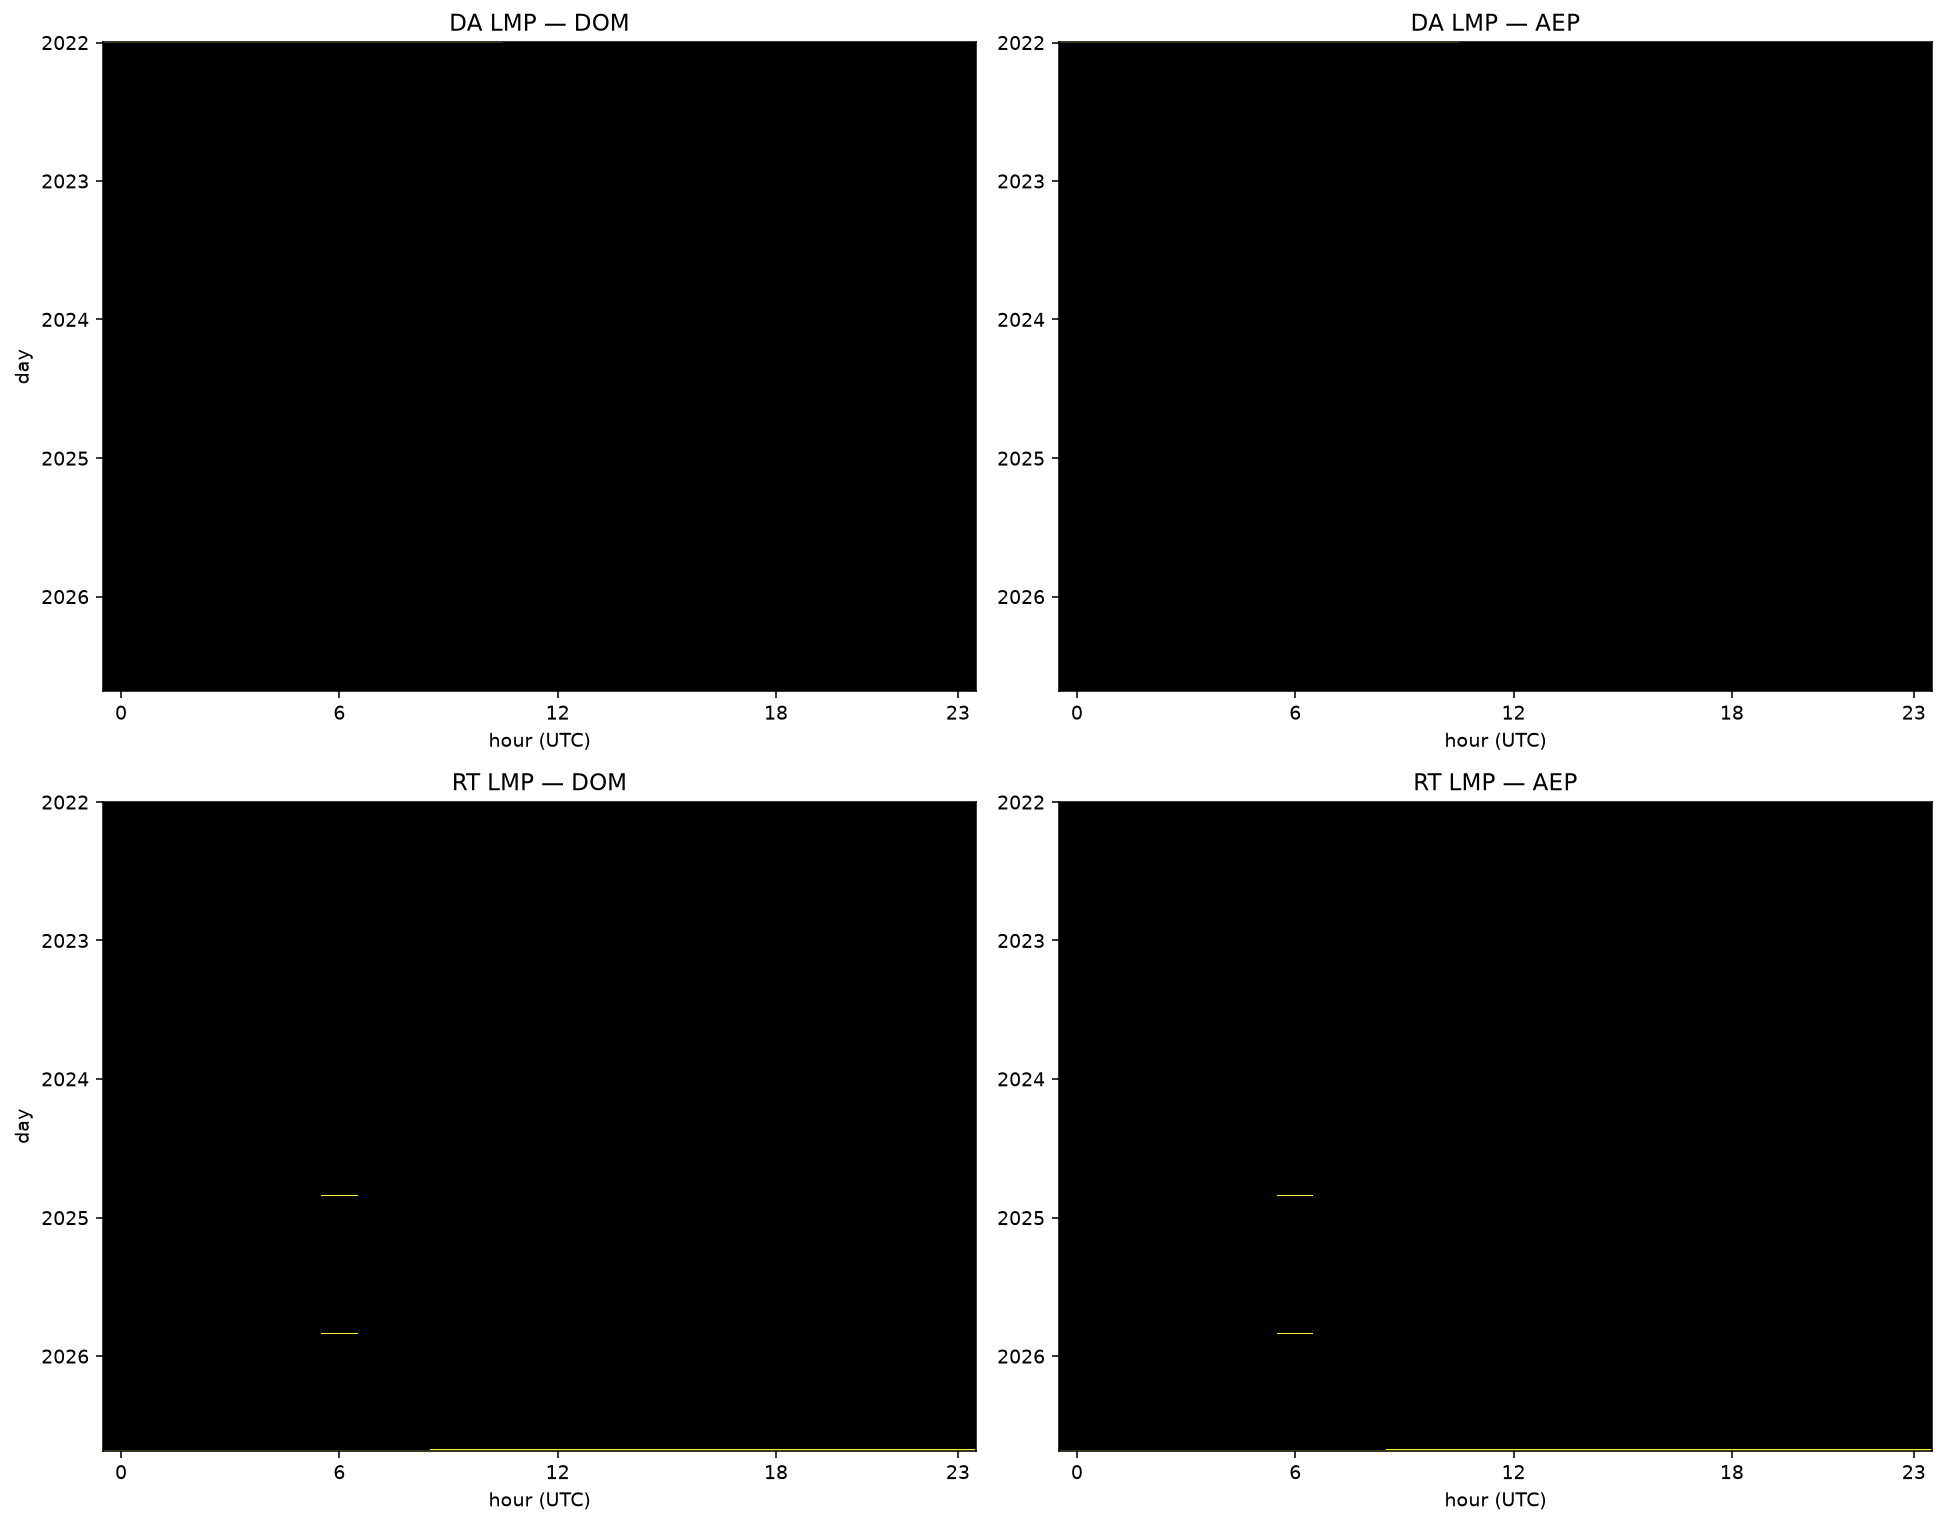

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11), dpi=140)

for row, feed in enumerate(FEEDS):
    for col, zone in enumerate(ZONES_HERE):
        ax = axes[row, col]
        grid = grids[(feed, zone)]
        bad = (~grid).astype(int).values
        ax.imshow(bad, cmap=cmap, vmin=0, vmax=1, aspect='auto', interpolation='none')
        ax.set_title(f'{feed} LMP — {zone}')
        ax.set_xlabel('hour (UTC)')
        ax.set_xticks([0, 6, 12, 18, 23])

        year_starts = [i for i, d in enumerate(grid.index) if d.month == 1 and d.day == 1]
        ax.set_yticks(year_starts)
        ax.set_yticklabels([grid.index[i].year for i in year_starts])

axes[0, 0].set_ylabel('day')
axes[1, 0].set_ylabel('day')
plt.tight_layout()
plt.show()

## 3. Zoomed recent window (last 120 days)

Same encoding, sliced to full row-height detail so any near-term gap is unambiguous.

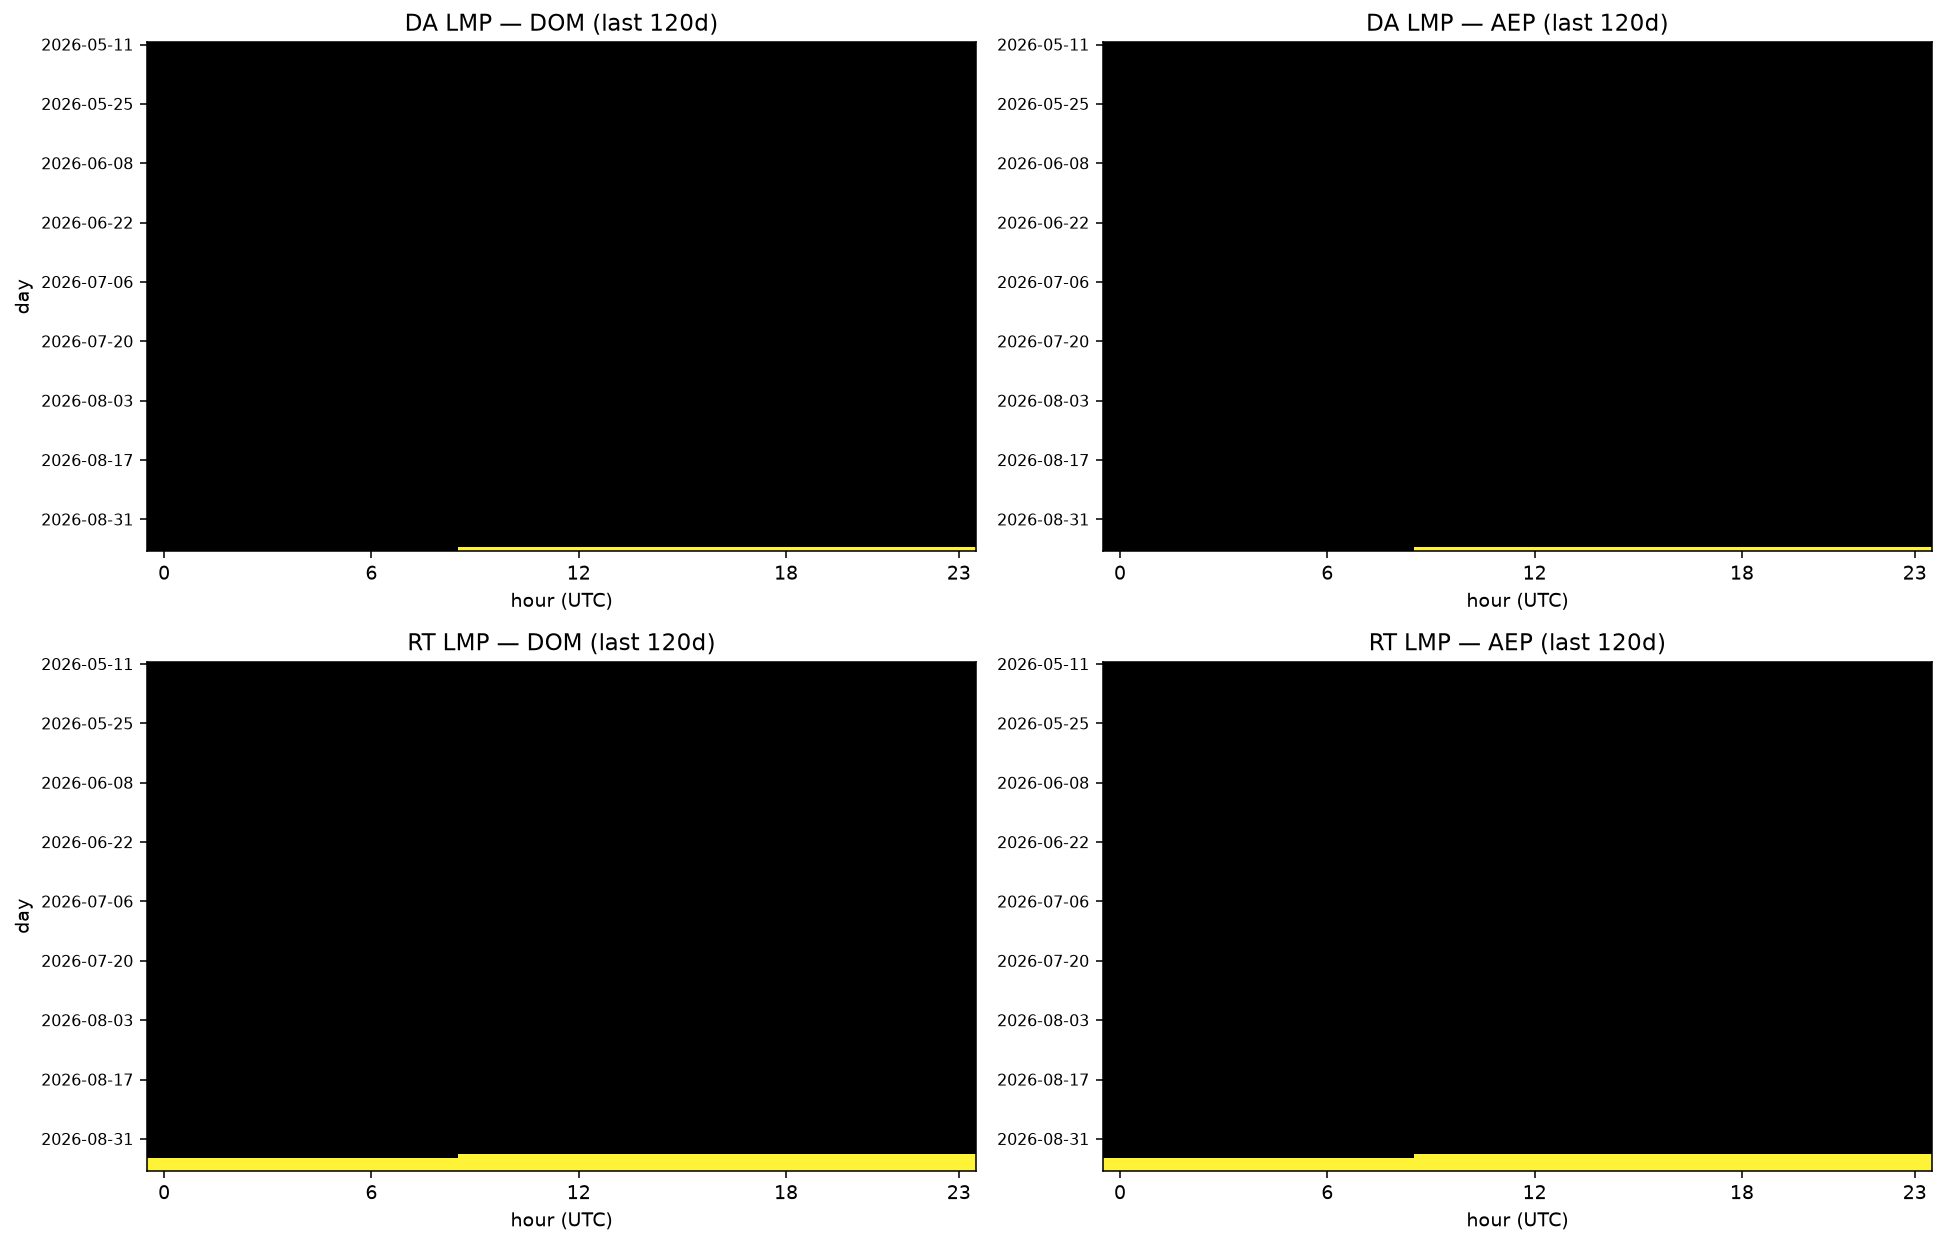

In [4]:
ZOOM_DAYS = 120

fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=140)

for row, feed in enumerate(FEEDS):
    for col, zone in enumerate(ZONES_HERE):
        ax = axes[row, col]
        grid = grids[(feed, zone)].iloc[-ZOOM_DAYS:]
        bad = (~grid).astype(int).values
        ax.imshow(bad, cmap=cmap, vmin=0, vmax=1, aspect='auto', interpolation='none')
        ax.set_title(f'{feed} LMP — {zone} (last {ZOOM_DAYS}d)')
        ax.set_xlabel('hour (UTC)')
        ax.set_xticks([0, 6, 12, 18, 23])

        tick_idx = list(range(0, len(grid), 14))
        ax.set_yticks(tick_idx)
        ax.set_yticklabels([grid.index[i].strftime('%Y-%m-%d') for i in tick_idx], fontsize=8)

axes[0, 0].set_ylabel('day')
axes[1, 0].set_ylabel('day')
plt.tight_layout()
plt.show()

## 4. Gap summary table

Contiguous missing-hour windows, run-length encoded, restricted to each series' own
observed range (so the RT recency tail and the day-one partial backfill start don't show
up as false "gaps") and excluding the known DST hour. Sorted by size, worst first.

In [5]:
gap_rows = []

for (feed, zone), grid in grids.items():
    own_lo, own_hi = own_range[(feed, zone)]
    present = grid.stack()
    present.index = present.index.map(lambda x: x[0] + pd.Timedelta(hours=x[1]))
    present = present.sort_index()
    missing = ~present
    missing = missing[(missing.index >= own_lo) & (missing.index <= own_hi)]

    is_dst = (missing.index.month == DST_MONTH) & (missing.index.hour == DST_HOUR)
    flagged = missing & ~is_dst

    if flagged.any():
        run_id = (flagged != flagged.shift()).cumsum()
        for _, g in flagged[flagged].groupby(run_id[flagged]):
            gap_rows.append({
                'feed': feed, 'zone': zone,
                'start': g.index.min(), 'end': g.index.max(),
                'hours_missing': len(g),
            })

gaps = pd.DataFrame(gap_rows)
if len(gaps):
    gaps = gaps.sort_values('hours_missing', ascending=False).reset_index(drop=True)
else:
    gaps = pd.DataFrame(columns=['feed', 'zone', 'start', 'end', 'hours_missing'])

print(f"{len(gaps)} gap window(s) found (excluding DST + recency-lag tail)")
gaps

0 gap window(s) found (excluding DST + recency-lag tail)


,feed,zone,start,end,hours_missing
